In [1]:
# import statements
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import fetch_openml

In [2]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True) # getting data from online
print('X shape:', X.shape, 'y shape:', y.shape)

X shape: (70000, 784) y shape: (70000,)


In [3]:
X = X.values # this converts X from a pandas dataframe to a numpy array

digits = {j:[] for j in range(10)}
for j in range(len(y)): # takes data assigns it into a dictionary
    digits[int(y[j])].append(X[j].reshape(28,28))
digits = {j:np.stack(digits[j]) for j in range(10)} # stack everything to be one numpy array
for j in range(10):
    print('Shape of data with label', j, ':', digits[j].shape )

Shape of data with label 0 : (6903, 28, 28)
Shape of data with label 1 : (7877, 28, 28)
Shape of data with label 2 : (6990, 28, 28)
Shape of data with label 3 : (7141, 28, 28)
Shape of data with label 4 : (6824, 28, 28)
Shape of data with label 5 : (6313, 28, 28)
Shape of data with label 6 : (6876, 28, 28)
Shape of data with label 7 : (7293, 28, 28)
Shape of data with label 8 : (6825, 28, 28)
Shape of data with label 9 : (6958, 28, 28)


In [4]:
data = []
for i in range(10):
    flattened_images = digits[i][:100].reshape(100,-1)
    data.append(flattened_images)
    
data = np.vstack(data)
data = data.astype('float32') / 255.0

In [5]:
X49 = np.vstack([digits[4][:500], digits[9][:500]])
y49 = np.hstack([-np.ones(500, dtype=np.int8), np.ones(500, dtype=np.int8)])

X49 = X49.reshape(1000, 784).astype("float") / 255.0

rng = np.random.default_rng(0)
perm = rng.permutation(len(y49))
X49, y49 = X49[perm], y49[perm]

In [17]:
def F(w, X, y):
    z = y * (X @ w)
    return np.mean(np.log(1 + np.exp(-z)))

def grad_F(w, X, y):
    z = y * (X @ w)
    s = 1 / (1 + np.exp(z))
    return -(X.T @ (y * s)) / len(y)


In [18]:
def gd_momentum(X, y, mu=0.01, beta=0.9, iters=100):
    features = X.shape[1]
    w_prev = np.zeros(features)
    w = np.zeros(features)

    hist = []

    for k in range(iters):
        g = grad_F(w, X, y)
        momentum = beta * (w - w_prev)

        w_next = w - mu * g + momentum

        w_prev = w
        w = w_next

        hist.append(F(w, X, y))

    return w, hist

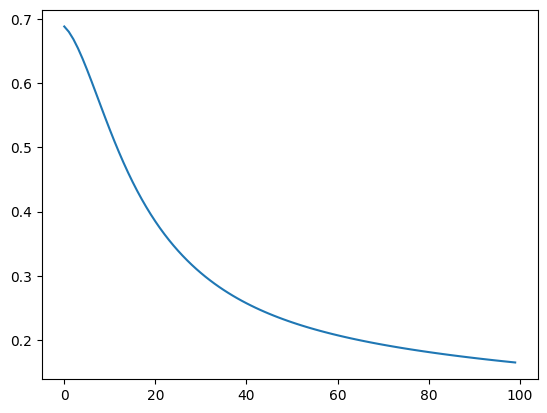

In [19]:
w_momentum, hist_momentum = gd_momentum(X49, y49, mu=0.01, beta=0.9, iters=100)
plt.plot(hist_momentum)

In [20]:
def gd_nesterov(X, y, mu=0.01, beta=0.9, iters=100):
    features = X.shape[1]
    w_prev = np.zeros(features)
    w = np.zeros(features)

    hist = []

    for k in range(iters):
        y_k = w + beta * (w - w_prev)

        g = grad_F(y_k, X, y) 

        w_next = y_k - mu * g

        w_prev = w
        w = w_next

        hist.append(F(w, X, y))

    return w, hist


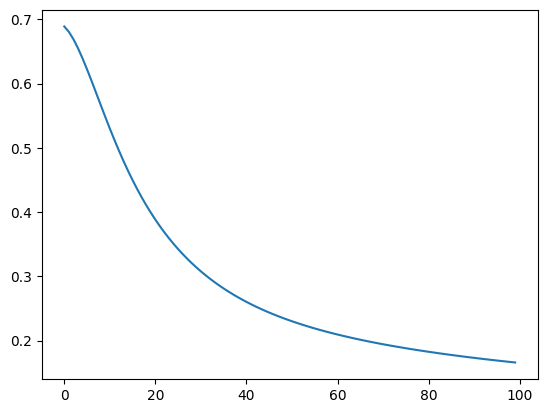

In [21]:
w_nes, hist_nes = gd_nesterov(X49, y49, mu=0.01, beta=0.9, iters=100)
plt.plot(hist_nes)
plt.show()
